# Electrode Event Predictions (Half-Electrode Holdout in aa)

## Step 0 - Imports and Settings

In [36]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat
from scipy.stats import pearsonr
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

# Paths
preprocessed_dir = Path('/Users/rustin/Documents/Big Data 567/All_Locs_MNI_and_Ecog_Preprocessed')
raw_data_root = Path('/Users/rustin/Documents/Big Data 567/faces_basic/data')

# Main settings
holdout_pid = 'aa'
holdout_fraction = 0.5
random_seed = 7
lambda_width = 20.0
ridge = 1.0

print('holdout_pid =', holdout_pid)
print('holdout_fraction =', holdout_fraction)
print('random_seed =', random_seed)
print('lambda_width =', lambda_width)
print('ridge =', ridge)

holdout_pid = aa
holdout_fraction = 0.5
random_seed = 7
lambda_width = 20.0
ridge = 1.0


## Step 1 - Helper Functions

In [37]:
def zscore_cols(x, eps=1e-6):
    x = np.asarray(x, dtype=np.float32)
    mu = x.mean(axis=0, keepdims=True)
    sd = x.std(axis=0, keepdims=True)
    sd[sd < eps] = 1.0
    return (x - mu) / sd


def coord_key(coord, decimals=3):
    return tuple(np.round(np.asarray(coord, dtype=np.float32), decimals).tolist())


def row_normalize(W, eps=1e-12):
    W = np.asarray(W, dtype=np.float32)
    s = W.sum(axis=1)
    out = np.zeros_like(W, dtype=np.float32)
    valid = s > eps
    out[valid] = W[valid] / s[valid, None]
    return out


def event_means_from_preprocessed_and_stim(ecog, stim_raw):
    stim_raw = np.asarray(stim_raw).ravel()
    stim_nz = stim_raw[stim_raw != 0]

    if stim_nz.shape[0] != ecog.shape[0]:
        raise ValueError(f'stim_nz length ({stim_nz.shape[0]}) != ecog rows ({ecog.shape[0]})')

    starts = np.r_[0, 1 + np.where(stim_nz[1:] != stim_nz[:-1])[0]]
    ends = np.r_[starts[1:], stim_nz.shape[0]]

    event_ids = stim_nz[starts].astype(np.int32)
    event_means = np.zeros((starts.shape[0], ecog.shape[1]), dtype=np.float32)

    for i, (a, b) in enumerate(zip(starts, ends)):
        event_means[i] = ecog[a:b].mean(axis=0)

    return event_means, event_ids


def face_house_label(event_id):
    # house: 1..50, face: 51..100
    if 1 <= event_id <= 50:
        return 0
    if 51 <= event_id <= 100:
        return 1
    return -1


def build_task_events(event_means, event_ids):
    y = np.array([face_house_label(int(v)) for v in event_ids], dtype=int)
    keep = y >= 0
    return event_means[keep], y[keep], event_ids[keep]


def fisher_z(x):
    x = np.asarray(x, dtype=np.float32)
    x = np.clip(x, -0.999999, 0.999999)
    return np.arctanh(x)


def inverse_fisher_z(z):
    return np.tanh(z)


def corrcoef_cols(X):
    X = np.asarray(X, dtype=np.float32)
    C = np.corrcoef(X, rowvar=False)
    C = np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)
    C = np.clip(C, -1.0, 1.0)
    np.fill_diagonal(C, 1.0)
    return C


def make_three_contiguous_folds(n):
    a = np.arange(n)
    b1 = n // 3
    b2 = (2 * n) // 3
    fold_test = [a[:b1], a[b1:b2], a[b2:]]
    folds = []
    for te in fold_test:
        tr = np.setdiff1d(a, te)
        folds.append((tr, te))
    return folds


def decode_lda_cv(X, y, verbose=True):
    folds = make_three_contiguous_folds(len(y))
    yhat = np.full_like(y, fill_value=-1)
    fold_acc = []

    for i, (tr, te) in enumerate(folds, start=1):
        clf = LinearDiscriminantAnalysis()
        clf.fit(X[tr], y[tr])
        pred = clf.predict(X[te])
        yhat[te] = pred
        acc = accuracy_score(y[te], pred)
        fold_acc.append(acc)
        if verbose:
            print(f'  fold {i}: n_train={len(tr)} n_test={len(te)} acc={acc:.3f}')

    overall = accuracy_score(y, yhat)
    return overall, np.array(fold_acc), yhat


def safe_corr(x, y):
    if np.std(x) < 1e-8 or np.std(y) < 1e-8:
        return np.nan
    return pearsonr(x, y).statistic

## Step 2 - Load All Subjects and Build Event Matrices

In [38]:
npz_files = sorted(preprocessed_dir.glob('*_preprocessed.npz'))
assert len(npz_files) > 0, f'No *_preprocessed.npz files in {preprocessed_dir}'

subject_records = {}
for f in npz_files:
    pid = f.stem.replace('_preprocessed', '')
    rec = np.load(f, allow_pickle=True)

    ecog = np.asarray(rec['ecog'], dtype=np.float32)
    ecog_z = zscore_cols(ecog)
    locs = np.asarray(rec['locs_mni_mm'], dtype=np.float32)

    stim = loadmat(raw_data_root / pid / f'{pid}_faceshouses.mat')['stim'].ravel()
    ev_means, ev_ids = event_means_from_preprocessed_and_stim(ecog_z, stim)
    X_task, y_task, event_ids_task = build_task_events(ev_means, ev_ids)

    subject_records[pid] = {
        'locs': locs,
        'X_task': X_task,
        'y_task': y_task,
        'event_ids_task': event_ids_task,
    }

    print(f'[{pid}] X_task shape={X_task.shape}, locs={locs.shape}')

assert holdout_pid in subject_records, f'{holdout_pid} not found' 

[aa] X_task shape=(300, 41), locs=(41, 3)
[ap] X_task shape=(300, 40), locs=(40, 3)
[ca] X_task shape=(300, 49), locs=(49, 3)
[de] X_task shape=(300, 31), locs=(31, 3)
[fp] X_task shape=(300, 11), locs=(11, 3)
[ha] X_task shape=(300, 39), locs=(39, 3)
[ja] X_task shape=(300, 37), locs=(37, 3)
[jt] X_task shape=(300, 96), locs=(96, 3)
[mv] X_task shape=(300, 19), locs=(19, 3)
[rn] X_task shape=(300, 41), locs=(41, 3)
[rr] X_task shape=(200, 40), locs=(40, 3)
[wc] X_task shape=(300, 38), locs=(38, 3)
[zt] X_task shape=(300, 58), locs=(58, 3)


## Step 3 - Align All Subjects to Shared Event Prefix

In [39]:
n_events_common = min(v['X_task'].shape[0] for v in subject_records.values())
print('n_events_common =', n_events_common)

for pid, rec in subject_records.items():
    rec['X_common'] = rec['X_task'][:n_events_common]
    rec['y_common'] = rec['y_task'][:n_events_common]
    rec['event_ids_common'] = rec['event_ids_task'][:n_events_common]

ref_ids = subject_records[holdout_pid]['event_ids_common']
print('event-order match to holdout prefix:')
for pid, rec in sorted(subject_records.items()):
    same = np.array_equal(rec['event_ids_common'], ref_ids)
    print(f'  {pid}: {same}')

n_events_common = 200
event-order match to holdout prefix:
  aa: True
  ap: True
  ca: True
  de: True
  fp: True
  ha: True
  ja: True
  jt: True
  mv: True
  rn: True
  rr: True
  wc: True
  zt: True


## Step 4 - Build Pooled Electrode Space and Gaussian Weights

In [40]:
all_coords = []
for rec in subject_records.values():
    for c in rec['locs']:
        all_coords.append(coord_key(c, decimals=3))

pooled_keys = sorted(set(all_coords))
pooled_coords = np.array(pooled_keys, dtype=np.float32)
L = pooled_coords.shape[0]
print('pooled electrode count L =', L)

for pid, rec in subject_records.items():
    locs = rec['locs']
    d2 = ((pooled_coords[:, None, :] - locs[None, :, :]) ** 2).sum(axis=2)
    W = np.exp(-d2 / (lambda_width ** 2)).astype(np.float32)
    rec['W'] = row_normalize(W)
    rec['pooled_idx'] = np.array([pooled_keys.index(coord_key(c, 3)) for c in locs], dtype=int)

    print(f'[{pid}] W shape={rec["W"].shape}')

pooled electrode count L = 540
[aa] W shape=(540, 41)
[ap] W shape=(540, 40)
[ca] W shape=(540, 49)
[de] W shape=(540, 31)
[fp] W shape=(540, 11)
[ha] W shape=(540, 39)
[ja] W shape=(540, 37)
[jt] W shape=(540, 96)
[mv] W shape=(540, 19)
[rn] W shape=(540, 41)
[rr] W shape=(540, 40)
[wc] W shape=(540, 38)
[zt] W shape=(540, 58)


## Step 5 - Build Leakage-Free $K$ (exclude aa from training subjects)

In [41]:
train_pids = [pid for pid in sorted(subject_records.keys()) if pid != holdout_pid]
print('K training subjects:', train_pids)

full_list = []
for pid in train_pids:
    rec = subject_records[pid]
    C = corrcoef_cols(rec['X_common'])
    W = rec['W']
    C_hat = W @ C @ W.T
    C_hat = np.clip(C_hat, -0.999999, 0.999999)
    np.fill_diagonal(C_hat, 1.0)
    full_list.append(C_hat)

Z = np.stack([fisher_z(M) for M in full_list], axis=0)
K_hat_no_leak = inverse_fisher_z(np.mean(Z, axis=0))
K_hat_no_leak = np.nan_to_num(K_hat_no_leak, nan=0.0, posinf=0.0, neginf=0.0)
np.fill_diagonal(K_hat_no_leak, 1.0)

print('K_hat_no_leak shape:', K_hat_no_leak.shape)
print('K range:', float(K_hat_no_leak.min()), float(K_hat_no_leak.max()))

K training subjects: ['ap', 'ca', 'de', 'fp', 'ha', 'ja', 'jt', 'mv', 'rn', 'rr', 'wc', 'zt']
K_hat_no_leak shape: (540, 540)
K range: 0.13110105693340302 1.0


## Step 6 - Randomly Hold Out Half of aa Electrodes

In [42]:
aa = subject_records[holdout_pid]
X = aa['X_common']
y = aa['y_common']

n_elecs = X.shape[1]
rng = np.random.default_rng(random_seed)
perm = rng.permutation(n_elecs)
n_beta = n_elecs // 2
beta_local_idx = np.sort(perm[:n_beta])
alpha_local_idx = np.sort(perm[n_beta:])

print('aa electrodes total:', n_elecs)
print('alpha (observed):', alpha_local_idx.shape[0])
print('beta (held-out):', beta_local_idx.shape[0])
print('beta indices:', beta_local_idx)

alpha_pooled_idx = aa['pooled_idx'][alpha_local_idx]
beta_pooled_idx = aa['pooled_idx'][beta_local_idx]

Y_alpha = X[:, alpha_local_idx]
Y_beta_true = X[:, beta_local_idx]

print('Y_alpha shape:', Y_alpha.shape)
print('Y_beta_true shape:', Y_beta_true.shape)
print('class counts:', {int(k): int((y==k).sum()) for k in np.unique(y)})

aa electrodes total: 41
alpha (observed): 21
beta (held-out): 20
beta indices: [ 0  3  4  6  9 10 12 14 19 20 22 24 26 27 28 32 33 37 39 40]
Y_alpha shape: (200, 21)
Y_beta_true shape: (200, 20)
class counts: {0: 100, 1: 100}


## Step 7 - Reconstruct Held-Out Half (SuperEEG decoder)

In [43]:
Kaa = K_hat_no_leak[np.ix_(alpha_pooled_idx, alpha_pooled_idx)]
Kba = K_hat_no_leak[np.ix_(beta_pooled_idx, alpha_pooled_idx)]

Kaa = np.nan_to_num(Kaa, nan=0.0, posinf=0.0, neginf=0.0)
Kba = np.nan_to_num(Kba, nan=0.0, posinf=0.0, neginf=0.0)

Kaa_sym = 0.5 * (Kaa + Kaa.T)
vals, vecs = np.linalg.eigh(Kaa_sym)
vals = np.clip(vals, 1e-6, None)
Kaa_psd = (vecs * vals) @ vecs.T
Kaa_reg = Kaa_psd + ridge * np.eye(Kaa_psd.shape[0], dtype=np.float32)

D = Kba @ np.linalg.pinv(Kaa_reg, rcond=1e-6)
D = np.nan_to_num(D, nan=0.0, posinf=0.0, neginf=0.0)

Y_beta_pred = (D @ Y_alpha.T).T
Y_beta_pred = np.nan_to_num(Y_beta_pred, nan=0.0, posinf=0.0, neginf=0.0)

print('D shape:', D.shape)
print('Y_beta_pred shape:', Y_beta_pred.shape)
print('finite pred:', np.isfinite(Y_beta_pred).all())

D shape: (20, 21)
Y_beta_pred shape: (200, 20)
finite pred: True


## Step 8 - Quick Reconstruction Check

In [44]:
r_each = [safe_corr(Y_beta_true[:, j], Y_beta_pred[:, j]) for j in range(Y_beta_true.shape[1])]
r_each = np.array(r_each, dtype=float)
print('mean electrode r:', np.nanmean(r_each))
print('min/median/max r:', np.nanmin(r_each), np.nanmedian(r_each), np.nanmax(r_each))

mean electrode r: 0.36499588526273985
min/median/max r: -0.449207853979405 0.5042929686620061 0.7948284327646156


## Step 9 - Face/House Decoding (same simple 3-fold LDA style)

In [45]:
print('Decode with observed alpha electrodes:')
acc_alpha, folds_alpha, yhat_alpha = decode_lda_cv(Y_alpha, y)

print('\nDecode with true held-out beta electrodes:')
acc_beta_true, folds_beta_true, yhat_beta_true = decode_lda_cv(Y_beta_true, y)

print('\nDecode with reconstructed held-out beta electrodes:')
acc_beta_pred, folds_beta_pred, yhat_beta_pred = decode_lda_cv(Y_beta_pred, y)

print('\nOverall accuracies')
print('  alpha (observed):', f'{acc_alpha:.3f}')
print('  beta true:', f'{acc_beta_true:.3f}')
print('  beta reconstructed:', f'{acc_beta_pred:.3f}')

Decode with observed alpha electrodes:
  fold 1: n_train=134 n_test=66 acc=0.576
  fold 2: n_train=133 n_test=67 acc=0.612
  fold 3: n_train=133 n_test=67 acc=0.597

Decode with true held-out beta electrodes:
  fold 1: n_train=134 n_test=66 acc=0.621
  fold 2: n_train=133 n_test=67 acc=0.627
  fold 3: n_train=133 n_test=67 acc=0.642

Decode with reconstructed held-out beta electrodes:
  fold 1: n_train=134 n_test=66 acc=0.591
  fold 2: n_train=133 n_test=67 acc=0.597
  fold 3: n_train=133 n_test=67 acc=0.582

Overall accuracies
  alpha (observed): 0.595
  beta true: 0.630
  beta reconstructed: 0.590


## Step 10 - Plots

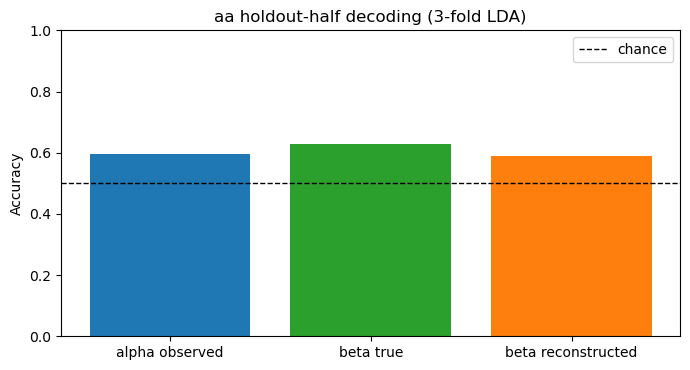

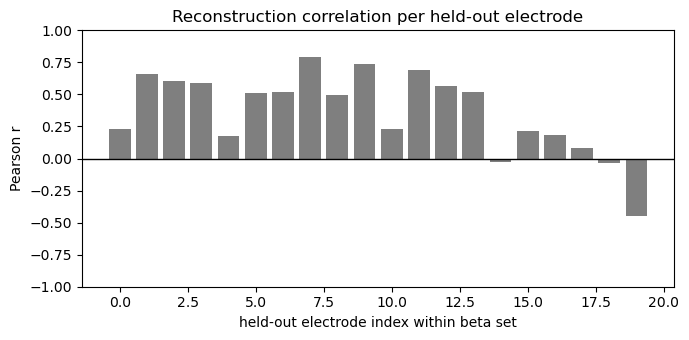

In [46]:
# Accuracy summary
labels = ['alpha observed', 'beta true', 'beta reconstructed']
vals = [acc_alpha, acc_beta_true, acc_beta_pred]

plt.figure(figsize=(7, 3.8))
plt.bar(labels, vals, color=['tab:blue', 'tab:green', 'tab:orange'])
plt.axhline(0.5, color='k', linestyle='--', linewidth=1, label='chance')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('aa holdout-half decoding (3-fold LDA)')
plt.legend()
plt.tight_layout()
plt.show()

# Electrode-wise reconstruction r
plt.figure(figsize=(7, 3.5))
plt.bar(np.arange(len(r_each)), r_each, color='tab:gray')
plt.axhline(0, color='k', linewidth=1)
plt.ylim(-1, 1)
plt.xlabel('held-out electrode index within beta set')
plt.ylabel('Pearson r')
plt.title('Reconstruction correlation per held-out electrode')
plt.tight_layout()
plt.show()

## Step 11 - Repeat Over Many Random Half-Holdout Splits

n_repeats = 20
alpha observed      mean ± std: 0.618 ± 0.069
beta true           mean ± std: 0.626 ± 0.074
beta reconstructed  mean ± std: 0.592 ± 0.054
mean recon r        mean ± std: 0.366 ± 0.036


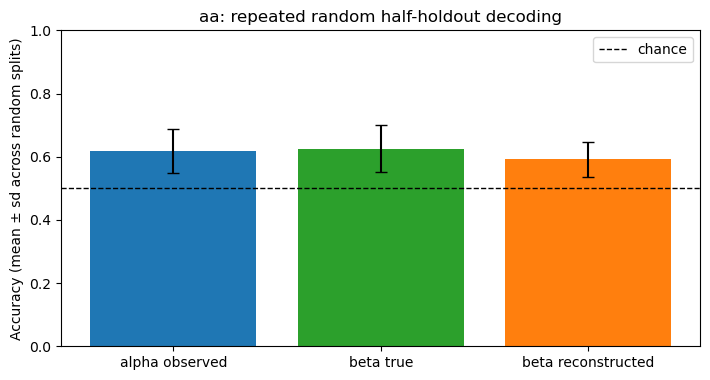

In [47]:
n_repeats = 20
seed_list = np.arange(n_repeats) + 100

acc_alpha_list = []
acc_beta_true_list = []
acc_beta_pred_list = []
mean_r_list = []

X = subject_records[holdout_pid]['X_common']
y = subject_records[holdout_pid]['y_common']
pooled_idx = subject_records[holdout_pid]['pooled_idx']

n_elecs = X.shape[1]
n_beta = int(np.floor(holdout_fraction * n_elecs))
n_beta = max(1, min(n_elecs - 1, n_beta))

for sd in seed_list:
    rng = np.random.default_rng(int(sd))
    perm = rng.permutation(n_elecs)

    beta_idx = np.sort(perm[:n_beta])
    alpha_idx = np.sort(perm[n_beta:])

    alpha_pool = pooled_idx[alpha_idx]
    beta_pool = pooled_idx[beta_idx]

    Y_a = X[:, alpha_idx]
    Y_b_true = X[:, beta_idx]

    Kaa = K_hat_no_leak[np.ix_(alpha_pool, alpha_pool)]
    Kba = K_hat_no_leak[np.ix_(beta_pool, alpha_pool)]

    Kaa = np.nan_to_num(Kaa, nan=0.0, posinf=0.0, neginf=0.0)
    Kba = np.nan_to_num(Kba, nan=0.0, posinf=0.0, neginf=0.0)

    Kaa_sym = 0.5 * (Kaa + Kaa.T)
    vals, vecs = np.linalg.eigh(Kaa_sym)
    vals = np.clip(vals, 1e-6, None)
    Kaa_psd = (vecs * vals) @ vecs.T
    Kaa_reg = Kaa_psd + ridge * np.eye(Kaa_psd.shape[0], dtype=np.float32)

    D = Kba @ np.linalg.pinv(Kaa_reg, rcond=1e-6)
    D = np.nan_to_num(D, nan=0.0, posinf=0.0, neginf=0.0)
    Y_b_pred = (D @ Y_a.T).T

    ra = decode_lda_cv(Y_a, y, verbose=False)[0]
    rbt = decode_lda_cv(Y_b_true, y, verbose=False)[0]
    rbp = decode_lda_cv(Y_b_pred, y, verbose=False)[0]

    r_each_loop = np.array([safe_corr(Y_b_true[:, j], Y_b_pred[:, j]) for j in range(Y_b_true.shape[1])], dtype=float)
    mean_r = np.nanmean(r_each_loop)

    acc_alpha_list.append(ra)
    acc_beta_true_list.append(rbt)
    acc_beta_pred_list.append(rbp)
    mean_r_list.append(mean_r)

acc_alpha_arr = np.array(acc_alpha_list)
acc_beta_true_arr = np.array(acc_beta_true_list)
acc_beta_pred_arr = np.array(acc_beta_pred_list)
mean_r_arr = np.array(mean_r_list)

print('n_repeats =', n_repeats)
print('alpha observed      mean ± std:', f'{acc_alpha_arr.mean():.3f} ± {acc_alpha_arr.std(ddof=1):.3f}')
print('beta true           mean ± std:', f'{acc_beta_true_arr.mean():.3f} ± {acc_beta_true_arr.std(ddof=1):.3f}')
print('beta reconstructed  mean ± std:', f'{acc_beta_pred_arr.mean():.3f} ± {acc_beta_pred_arr.std(ddof=1):.3f}')
print('mean recon r        mean ± std:', f'{mean_r_arr.mean():.3f} ± {mean_r_arr.std(ddof=1):.3f}')

labels = ['alpha observed', 'beta true', 'beta reconstructed']
means = [acc_alpha_arr.mean(), acc_beta_true_arr.mean(), acc_beta_pred_arr.mean()]
errs = [acc_alpha_arr.std(ddof=1), acc_beta_true_arr.std(ddof=1), acc_beta_pred_arr.std(ddof=1)]

plt.figure(figsize=(7.2, 3.9))
plt.bar(labels, means, yerr=errs, capsize=4, color=['tab:blue', 'tab:green', 'tab:orange'])
plt.axhline(0.5, color='k', linestyle='--', linewidth=1, label='chance')
plt.ylim(0, 1)
plt.ylabel('Accuracy (mean ± sd across random splits)')
plt.title(f'{holdout_pid}: repeated random half-holdout decoding')
plt.legend()
plt.tight_layout()
plt.show()

## Notes

- This notebook now does exactly one setup: `aa` with **random 50% electrode holdout**.
- `K_hat_no_leak` is trained on all other subjects.
- Decoding uses simple 3-fold contiguous splits (same general style as your faces/houses workflow).
